In [19]:
import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
    

import numpy as np
import pandas as pd
from pathlib import Path

from core.data_org import BUNDLE_DIR
from strat.strat_backtest import (
    ETF_LIST,
    compute_dual_momentum,
    get_current_allocation,
)
from strat.strat_analysis import (
    print_allocation_summary,
    print_metrics,
    compute_period_returns,
)
from strat.strat_visualise import (
    ETF_COLORS,
    plot_normalized_prices,
    create_allocation_gif,
    plot_pnl_histogram,
    plot_portfolio_value,
    plot_allocation_history,
    plot_cumulative_pnl,
    plot_monthly_returns_chart,
    plot_detailed_diagnostics,
)
from backtest import (
    run_full_backtest,
    compute_strategy_metrics,
    save_backtest_diagnostics,
)

INPUT_FILE = Path("/data/bundle/test_etf_features_bundle.parquet")
OUTPUT_DIR = Path("/data/work/dual_momentum/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"ETF List: {ETF_LIST}")

Input file: /data/bundle/test_etf_features_bundle.parquet
Output directory: /data/work/dual_momentum
ETF List: ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO']


## Configuration

Configure strategy and backtest parameters:

In [21]:
STRATEGY_PARAMS = {
    'lookback': 240,  # ROC lookback period in bars
    'default_etf_idx': 2,  # TLT (safe haven)
    'top_n': 2,
    'abs_momentum_threshold': 0.01,
}

# Construct feature_id from lookback
STRATEGY_PARAMS['feature_id'] = f"F_roc_{STRATEGY_PARAMS['lookback']}_F_mid_f32_f16"

BACKTEST_PARAMS = {
    'rebalance_threshold': 0.05,
}

print("Strategy Parameters:")
for k, v in STRATEGY_PARAMS.items():
    print(f"  {k}: {v}")
print("\nBacktest Parameters:")
for k, v in BACKTEST_PARAMS.items():
    print(f"  {k}: {v}")

Strategy Parameters:
  lookback: 240
  default_etf_idx: 2
  top_n: 2
  abs_momentum_threshold: 0.01
  feature_id: F_roc_240_F_mid_f32_f16

Backtest Parameters:
  rebalance_threshold: 0.05


## Step 1: Load Data

Load the ETF features bundle:

In [22]:
df = pd.read_parquet(INPUT_FILE)
#df = df[48000:]
print(f"Loaded: {df.shape}")
print(f"Index: {df.index.name}, dtype: {df.index.dtype}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

etfs_in_bundle = sorted(set(c.split("_")[0] for c in df.columns if "_F_" in c))
print(f"\nETFs in bundle: {etfs_in_bundle}")

# Show available lookback values (from F_roc_* columns)
roc_cols = [c for c in df.columns if "_roc_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Available ROC lookbacks (bars): {available_lookbacks}")

feature_cols = [c for c in df.columns if STRATEGY_PARAMS['feature_id'] in c]
print(f"Feature columns found: {len(feature_cols)}")

Loaded: (48107, 611)
Index: None, dtype: int64
Date range: 0 to 48106

ETFs in bundle: ['GLD', 'QQQ', 'SPY', 'TLT', 'VWO']
Available ROC lookbacks (bars): [14, 60, 240]
Feature columns found: 5


In [23]:
!pip install numba


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
# Generate ROC for additional lookback periods
from features.feature_ta_utils import numba_roc

# Define periods: 1-7, 10, 20, 30, ..., 2400
periods = list(range(100, 2400, 100))
print(f"Generating ROC for {len(periods)} periods: {periods[:10]}...{periods[-3:]}")

etfs = ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO']
mid_col = "F_mid_f32"

# Build all new columns first, then concat once to avoid fragmentation
new_cols = {}
for etf in etfs:
    mid_price_col = f"{etf}_{mid_col}"
    
    for period in periods:
        col_name = f"{etf}_F_roc_{period}_{mid_col}_f16"
        if col_name not in df.columns:
            new_cols[col_name] = numba_roc(df[mid_price_col].to_numpy(), period)

# Add all columns at once
df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

print(f"DataFrame shape after ROC generation: {df.shape}")

# Update available lookbacks
roc_cols = [c for c in df.columns if "_roc_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Available ROC lookbacks: {len(available_lookbacks)} periods")
print(f"  First 10: {available_lookbacks[:10]}")
print(f"  Last 10: {available_lookbacks[-10:]}")

Generating ROC for 23 periods: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]...[2100, 2200, 2300]
DataFrame shape after ROC generation: (48107, 726)
Available ROC lookbacks: 26 periods
  First 10: [14, 60, 100, 200, 240, 300, 400, 500, 600, 700]
  Last 10: [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


## Step 2: Run Dual Momentum Strategy

Compute allocations using the dual momentum strategy:

In [7]:
df_allocations = compute_dual_momentum(
    p_df=df,
    p_feature_id=STRATEGY_PARAMS['feature_id'],
    p_default_etf_idx=STRATEGY_PARAMS['default_etf_idx'],
    p_top_n=STRATEGY_PARAMS['top_n'],
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
)

print(f"Allocations computed: {df_allocations.shape}")
print(f"\nAllocation columns: {[c for c in df_allocations.columns if c.startswith('A_')]}")

Allocations computed: (48107, 738)

Allocation columns: ['A_QQQ_alloc', 'A_SPY_alloc', 'A_TLT_alloc', 'A_GLD_alloc', 'A_VWO_alloc', 'A_top_etf', 'A_n_positive_momentum', 'A_QQQ_roc_rank', 'A_SPY_roc_rank', 'A_TLT_roc_rank', 'A_GLD_roc_rank', 'A_VWO_roc_rank']


## Step 3: ROC Period Sweep

Loop over all ROC periods and compute performance for top 1 and top 2 assets.

In [8]:
import matplotlib.pyplot as plt

def sweep_roc_periods(p_df, p_lookbacks, p_rebalance_threshold=0.05, p_abs_momentum_threshold=0.01, p_default_etf_idx=2):
    """
    Run dual momentum for different ROC periods and compute performance.
    
    Args:
        p_df: DataFrame with ROC columns and OHLC data
        p_lookbacks: List of ROC lookback periods to test
        p_rebalance_threshold: Rebalance threshold
        p_abs_momentum_threshold: Absolute momentum threshold
        p_default_etf_idx: Default ETF index (safe haven)
    
    Returns:
        dict with 'top1' and 'top2' lists of (period, total_return) tuples
    """
    from backtest import run_full_backtest, compute_strategy_metrics
    from strat.strat_backtest import compute_dual_momentum
    
    mid_col = "F_mid_f32"
    results = {
        'top1': [],
        'top2': [],
    }
    
    for lookback in p_lookbacks:
        feature_id = f"F_roc_{lookback}_{mid_col}_f16"
        
        # Compute allocations for this lookback
        df_alloc = compute_dual_momentum(
            p_df=p_df,
            p_feature_id=feature_id,
            p_default_etf_idx=p_default_etf_idx,
            p_top_n=1,
            p_abs_momentum_threshold=p_abs_momentum_threshold,
        )
        
        # Generate orders and compute performance for top_n=1
        orders_df, _ = run_full_backtest(df_alloc, p_rebalance_threshold)
        metrics_top1, _ = compute_strategy_metrics(df_alloc, orders_df)
        results['top1'].append((lookback, metrics_top1['total_return']))
        
        # Compute allocations for top_n=2
        df_alloc2 = compute_dual_momentum(
            p_df=p_df,
            p_feature_id=feature_id,
            p_default_etf_idx=p_default_etf_idx,
            p_top_n=2,
            p_abs_momentum_threshold=p_abs_momentum_threshold,
        )
        
        orders_df2, _ = run_full_backtest(df_alloc2, p_rebalance_threshold)
        metrics_top2, _ = compute_strategy_metrics(df_alloc2, orders_df2)
        results['top2'].append((lookback, metrics_top2['total_return']))
        
        print(f"Lookback {lookback:4d}: top1={metrics_top1['total_return']*100:7.2f}%, top2={metrics_top2['total_return']*100:7.2f}%")
    
    return results

In [9]:
# Get available lookbacks from the dataframe
roc_cols = [c for c in df.columns if "_roc_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Running ROC sweep over {len(available_lookbacks)} periods...")

# Run the sweep
results = sweep_roc_periods(
    p_df=df,
    p_lookbacks=available_lookbacks,
    p_rebalance_threshold=BACKTEST_PARAMS['rebalance_threshold'],
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
    p_default_etf_idx=STRATEGY_PARAMS['default_etf_idx'],
)

Running ROC sweep over 26 periods...
Lookback   14: top1= 151.26%, top2= -84.02%
Lookback   60: top1= 125.43%, top2= -18.18%
Lookback  100: top1= 134.82%, top2= -30.47%
Lookback  200: top1= 143.56%, top2= 604.07%
Lookback  240: top1= 265.92%, top2= 146.25%
Lookback  300: top1= 204.49%, top2= 374.56%
Lookback  400: top1= 525.12%, top2= 792.44%
Lookback  500: top1= 301.47%, top2= 742.95%
Lookback  600: top1= 437.59%, top2= 899.25%
Lookback  700: top1= 805.07%, top2=1479.10%
Lookback  800: top1= 660.45%, top2=1145.92%
Lookback  900: top1= 162.51%, top2= 613.18%
Lookback 1000: top1= 260.56%, top2=2627.39%
Lookback 1100: top1= 395.19%, top2=1194.60%
Lookback 1200: top1= 377.52%, top2=3544.80%
Lookback 1300: top1= 419.89%, top2=1812.88%
Lookback 1400: top1= 361.82%, top2=1560.44%
Lookback 1500: top1= 316.93%, top2=1390.42%
Lookback 1600: top1= 385.89%, top2=1190.80%
Lookback 1700: top1= 211.13%, top2=1653.45%
Lookback 1800: top1= 152.46%, top2=1306.11%
Lookback 1900: top1= 161.25%, top2=1401

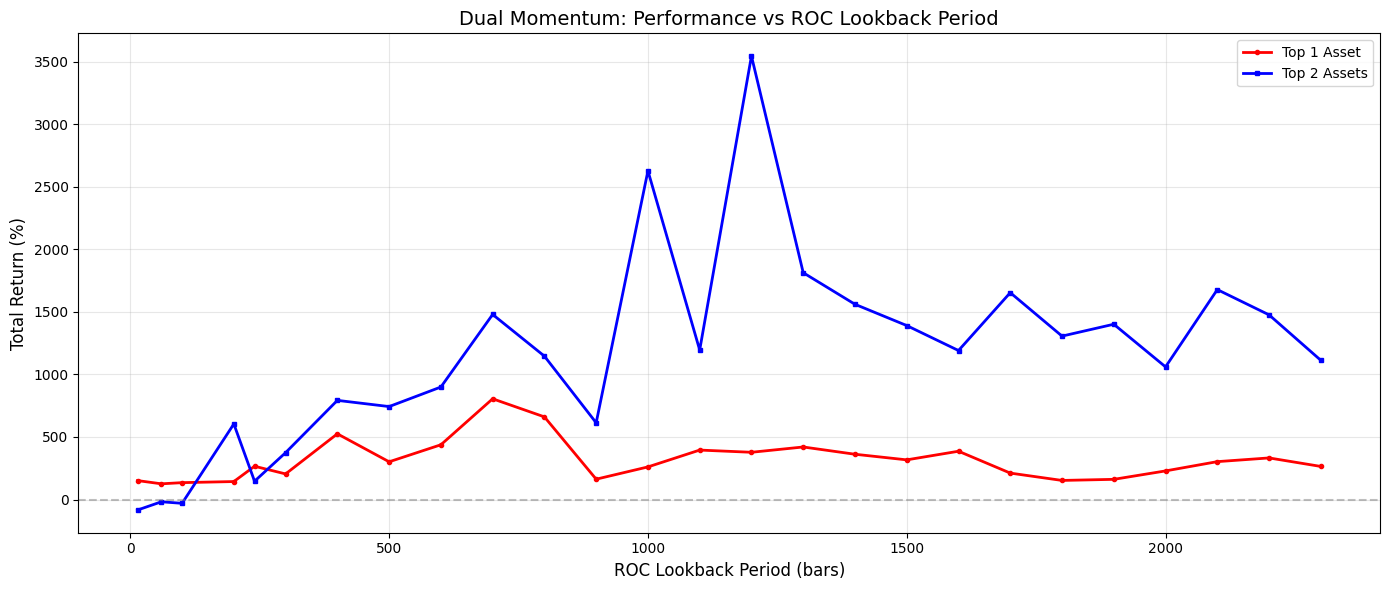


Best ROC lookback: Top1 = 700 bars (805.07%), Top2 = 1200 bars (3544.80%)


In [10]:
# Plot results
fig, ax = plt.subplots(figsize=(14, 6))

periods = [x[0] for x in results['top1']]
top1_returns = [x[1] * 100 for x in results['top1']]
top2_returns = [x[1] * 100 for x in results['top2']]

ax.plot(periods, top1_returns, 'r-', linewidth=2, label='Top 1 Asset', marker='o', markersize=3)
ax.plot(periods, top2_returns, 'b-', linewidth=2, label='Top 2 Assets', marker='s', markersize=3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('ROC Lookback Period (bars)', fontsize=12)
ax.set_ylabel('Total Return (%)', fontsize=12)
ax.set_title('Dual Momentum: Performance vs ROC Lookback Period', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best periods
best_top1 = max(results['top1'], key=lambda x: x[1])
best_top2 = max(results['top2'], key=lambda x: x[1])
print(f"\nBest ROC lookback: Top1 = {best_top1[0]} bars ({best_top1[1]*100:.2f}%), Top2 = {best_top2[0]} bars ({best_top2[1]*100:.2f}%)")

## Step 3: Analyze Current Allocation

Show current allocation and recent history:

In [25]:



df_allocations = compute_dual_momentum(
    p_df=df,
    p_feature_id='F_roc_1400_F_mid_f32_f16',
    p_default_etf_idx=STRATEGY_PARAMS['default_etf_idx'],
    p_top_n=2,
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
)

print(f"Allocations computed: {df_allocations.shape}")
print(f"\nAllocation columns: {[c for c in df_allocations.columns if c.startswith('A_')]}")

current_alloc = get_current_allocation(df_allocations)
print("Current Allocation:")
for etf, alloc in current_alloc.items():
    print(f"  {etf}: {alloc:.2%}")

print_allocation_summary(df_allocations, p_n_last=10)

Allocations computed: (48107, 738)

Allocation columns: ['A_QQQ_alloc', 'A_SPY_alloc', 'A_TLT_alloc', 'A_GLD_alloc', 'A_VWO_alloc', 'A_top_etf', 'A_n_positive_momentum', 'A_QQQ_roc_rank', 'A_SPY_roc_rank', 'A_TLT_roc_rank', 'A_GLD_roc_rank', 'A_VWO_roc_rank']
Current Allocation:
  QQQ: 0.00%
  SPY: 0.00%
  TLT: 0.00%
  GLD: 50.00%
  VWO: 50.00%

Recent Allocations (last 10 periods)
  48097: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48098: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48099: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48100: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48101: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48102: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48103: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48104: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48105: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5
  48106: GLD:0.50, VWO:0.50 | top: GLD | +mom: 5


## Step 4: Run Backtest

Generate orders and compute performance metrics:

In [26]:
orders_df, orders_list = run_full_backtest(
    p_df=df_allocations,
    p_rebalance_threshold=BACKTEST_PARAMS['rebalance_threshold'],
)

print(f"Generated {len(orders_df)} orders")
print(f"\nOrders sample:")
print(orders_df.head(10))

Generated 2946 orders

Orders sample:
   timestamp  etf  direction      size       price  allocation
0          0  TLT        1.0  0.009370  106.719162         1.0
1       1400  TLT       -1.0  0.008829  113.262856         0.0
2       1400  GLD        1.0  0.004291  116.527779         0.5
3       1400  VWO        1.0  0.004055  123.303406         0.5
4       2837  SPY        1.0  0.004957  100.861633         0.5
5       2837  GLD       -1.0  0.003695  135.324066         0.0
6       2838  SPY       -1.0  0.004959  100.832077         0.0
7       2838  GLD        1.0  0.003690  135.486115         0.5
8       2853  SPY        1.0  0.004949  101.038780         0.5
9       2853  VWO       -1.0  0.003555  140.629929         0.0


In [27]:
metrics, df_backtest = compute_strategy_metrics(
    p_df=df_allocations,
    p_orders_df=orders_df,
)

print(f"Backtest result shape: {df_backtest.shape}")
print(f"\nNew columns: {[c for c in df_backtest.columns if c not in df_allocations.columns]}")

Backtest result shape: (48107, 741)

New columns: ['pnl_per_bar', 'cum_pnl', 'portfolio_value']


## Step 5: Performance Metrics

Display strategy performance metrics:

In [28]:
print_metrics(metrics)

metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
print("\nMetrics DataFrame:")
print(metrics_df)


STRATEGY PERFORMANCE METRICS

                          Returns                           
------------------------------------------------------------
  Total PnL:              15.6044 (1560.44%)
  Final Portfolio Value:  4.2947
  PnL per Bar:            0.000070
  PnL per Month:          0.2335

                        Risk Metrics                        
------------------------------------------------------------
  Max Drawdown:           -0.1926 (-19.26%)
  Sharpe Ratio:           6.5708
  Calmar Ratio:           1.0439

                      Trade Statistics                      
------------------------------------------------------------
  Number of Trades:       2946
  Win Rate:               47.02%
  Avg Win:                0.014317
  Avg Loss:               -0.008401
  Avg Win/Loss Ratio:     1.7042
  Profit Factor:          1.5127

                       Bar Statistics                       
------------------------------------------------------------
  Total Bars:        

## Step 6: Period Returns

Compute monthly and yearly returns:

In [29]:
try:
    monthly_returns, yearly_returns = compute_period_returns(df_backtest)
except ValueError:
    df_backtest.index = pd.date_range(start="2020-01-01", periods=len(df_backtest), freq="h")
    monthly_returns, yearly_returns = compute_period_returns(df_backtest)

print(f"Monthly returns: {monthly_returns.shape}")
print(f"Yearly returns: {yearly_returns.shape}")

print("\nMonthly Returns (last 12 months):")
print(monthly_returns.tail(12))

print("\nYearly Returns:")
print(yearly_returns)

Monthly returns: (65, 6)
Yearly returns: (5, 6)

Monthly Returns (last 12 months):
      month    return  n_bars  positive_bars  negative_bars  win_rate
53  2004-07  0.055367     720            499            221  0.693056
54  2004-08  0.085378     720            720              0  1.000000
55  2004-09  0.049089     720            714              6  0.991667
56  2004-10  0.302471     720            720              0  1.000000
57  2004-11  0.241134     720            713              7  0.990278
58  2004-12  0.163716     720            582            138  0.808333
59  2005-01  0.062418     720            613            107  0.851389
60  2005-02 -0.073338     720            260            460  0.361111
61  2005-03  0.080880     720            627             93  0.870833
62  2005-04  0.073509     720            714              6  0.991667
63  2005-05 -0.032859     720            497            223  0.690278
64  2005-06  0.014901     587             89              0  0.151618

Yearly

## Step 7: Generate Visualizations

Create and save all charts:

In [30]:
print("Generating visualizations...\n")

plot_normalized_prices(df, OUTPUT_DIR / "normalized_prices.png")
plot_allocation_history(df_backtest, OUTPUT_DIR / "allocation_history.png")
plot_portfolio_value(df_backtest, OUTPUT_DIR / "portfolio_value.png")
plot_cumulative_pnl(df_backtest, OUTPUT_DIR / "cumulative_pnl.png")
plot_pnl_histogram(df_backtest, OUTPUT_DIR / "pnl_histogram.png")
plot_monthly_returns_chart(monthly_returns, OUTPUT_DIR / "monthly_returns.png")
create_allocation_gif(df_allocations, OUTPUT_DIR / "allocation_evolution.gif", p_fps=10)

print(f"\nAll charts saved to: {OUTPUT_DIR}")

Generating visualizations...

Saved: /data/work/dual_momentum/normalized_prices.png
Saved allocation history: /data/work/dual_momentum/allocation_history.png
Saved portfolio value chart: /data/work/dual_momentum/portfolio_value.png
Saved cumulative PnL chart: /data/work/dual_momentum/cumulative_pnl.png
Saved PnL histogram: /data/work/dual_momentum/pnl_histogram.png
Saved monthly returns chart: /data/work/dual_momentum/monthly_returns.png
Saved: /data/work/dual_momentum/allocation_evolution.gif

All charts saved to: /data/work/dual_momentum


## Step 8: Save Diagnostics

Save all backtest results to files:

In [31]:
save_backtest_diagnostics(
    p_result_df=df_backtest,
    p_orders_df=orders_df,
    p_monthly_returns=monthly_returns,
    p_yearly_returns=yearly_returns,
    p_metrics=metrics,
    p_output_dir=OUTPUT_DIR,
)

print(f"\nDiagnostics saved to: {OUTPUT_DIR}")

Saved orders: /data/work/dual_momentum/orders.csv
Saved backtest result: /data/work/dual_momentum/backtest_result.parquet
Saved monthly returns: /data/work/dual_momentum/monthly_returns.csv
Saved yearly returns: /data/work/dual_momentum/yearly_returns.csv
Saved metrics: /data/work/dual_momentum/metrics.txt

Diagnostics saved to: /data/work/dual_momentum


In [32]:
# Detailed diagnostics with hourly candles and trades
plot_detailed_diagnostics(
    p_df=df_backtest,
    p_orders_df=orders_df,
    p_output_dir=OUTPUT_DIR / "detailed",
    p_n_bars=500,
)


Saved portfolio value chart: /data/work/dual_momentum/detailed/portfolio_value.png
Saved PnL histogram: /data/work/dual_momentum/detailed/pnl_histogram.png
Saved allocation history: /data/work/dual_momentum/detailed/allocation_history.png
Saved: /data/work/dual_momentum/detailed/trades_QQQ.png
Saved: /data/work/dual_momentum/detailed/trades_SPY.png
Saved: /data/work/dual_momentum/detailed/trades_TLT.png
Saved: /data/work/dual_momentum/detailed/trades_GLD.png
Saved: /data/work/dual_momentum/detailed/trades_VWO.png
All diagnostics saved to: /data/work/dual_momentum/detailed


## Summary

### Exposed Variables

**DataFrames:**
- `df` - Raw input data
- `df_allocations` - Data with allocation columns (output of compute_dual_momentum)
- `df_backtest` - Full backtest results with PnL columns
- `orders_df` - Generated orders
- `monthly_returns` - Monthly returns summary
- `yearly_returns` - Yearly returns summary

**Dicts:**
- `current_alloc` - Current portfolio allocation
- `metrics` - Performance metrics dictionary
- `STRATEGY_PARAMS` - Strategy configuration
- `BACKTEST_PARAMS` - Backtest configuration

### Output Files

Charts:
- `normalized_prices.png` - Normalized ETF prices
- `allocation_history.png` - Stacked allocation history
- `portfolio_value.png` - Portfolio value with drawdown
- `cumulative_pnl.png` - Cumulative PnL
- `pnl_histogram.png` - PnL distribution
- `monthly_returns.png` - Monthly returns bar chart
- `allocation_evolution.gif` - Animated allocation GIF

Data files:
- `orders.csv` - All generated orders
- `backtest_result.parquet` - Full backtest results
- `monthly_returns.csv` - Monthly returns data
- `yearly_returns.csv` - Yearly returns data
- `metrics.txt` - Performance metrics

In [34]:
print("=== DIAGNOSTIC ===")
print(f"Allocations sum per row (should be ~1.0):")
alloc_cols = [f"A_{etf}_alloc" for etf in ["QQQ", "SPY", "TLT", "GLD", "VWO"]]
print(df_allocations[alloc_cols].sum(axis=1).describe())
print(f"\nClose prices sample:")
close_cols = [f"{etf}_S_close_f32" for etf in ["QQQ", "SPY", "TLT", "GLD", "VWO"]]
print(df[close_cols].head(10))
print(f"\nPct change sample for QQQ:")
print(df["QQQ_S_close_f32"].pct_change().describe())

=== DIAGNOSTIC ===
Allocations sum per row (should be ~1.0):
count    48107.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

Close prices sample:
   QQQ_S_close_f32  SPY_S_close_f32  TLT_S_close_f32  GLD_S_close_f32  \
0        39.023914        86.905136       106.719162       102.060188   
1        38.722614        86.568451       106.442993       101.967590   
2        38.681034        86.539825       106.298836       102.337959   
3        38.836868        86.661530       106.586922       102.176620   
4        38.992699        86.962364       106.742996       102.291664   
5        38.930389        86.840668       107.115189       102.337959   
6        38.982334        86.804817       106.875237       102.222221   
7        39.210838        87.062683       106.671036       102.685188   
8        38.816135        86.554192       106.298836       102.893517   
9        38.743465        86.575684 

In [26]:
df.columns

Index(['QQQ_S_open_f32', 'QQQ_S_high_f32', 'QQQ_S_low_f32', 'QQQ_S_close_f32',
       'QQQ_S_volume_f64', 'QQQ_S_open_time_i', 'QQQ_S_close_time_i',
       'QQQ_minute_diff', 'QQQ_gap_flag', 'QQQ_valid_row',
       ...
       'VWO_F_diff_rel_ema_2_F_mid_f32_2_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_15_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_60_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_240_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_500_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_1440_f16', 'VWO_F_acc_dist_index_f64',
       'VWO_F_roc_14_F_mid_f32_f16', 'VWO_F_roc_60_F_mid_f32_f16',
       'VWO_F_roc_240_F_mid_f32_f16'],
      dtype='str', length=611)

In [27]:
df_allocations.columns

Index(['QQQ_S_open_f32', 'QQQ_S_high_f32', 'QQQ_S_low_f32', 'QQQ_S_close_f32',
       'QQQ_S_volume_f64', 'QQQ_S_open_time_i', 'QQQ_S_close_time_i',
       'QQQ_minute_diff', 'QQQ_gap_flag', 'QQQ_valid_row',
       ...
       'A_TLT_alloc', 'A_GLD_alloc', 'A_VWO_alloc', 'A_top_etf',
       'A_n_positive_momentum', 'A_QQQ_roc_rank', 'A_SPY_roc_rank',
       'A_TLT_roc_rank', 'A_GLD_roc_rank', 'A_VWO_roc_rank'],
      dtype='str', length=623)

In [28]:
returns_matrix = np.zeros(len(df))
portfolio_alloc = df_allocations[alloc_cols].values
for j, etf in enumerate(["QQQ", "SPY", "TLT", "GLD", "VWO"]):
    close_col = f"{etf}_S_close_f32"
    etf_returns = df[close_col].pct_change().fillna(0).values
    contrib = portfolio_alloc[:, j] * etf_returns
    returns_matrix += contrib
    print(f"{etf}: mean_return={etf_returns.mean():.6f}, mean_alloc={portfolio_alloc[:, j].mean():.3f}, max_contribution={contrib.max():.6f}")
print(f"\nreturns_matrix: mean={returns_matrix.mean():.6f}, std={returns_matrix.std():.6f}")
print(f"Max return in matrix: {returns_matrix.max():.6f}")
print(f"Any inf/nan? inf={np.isinf(returns_matrix).sum()}, nan={np.isnan(returns_matrix).sum()}")
# Check cumulative product
portfolio_value = (1 + returns_matrix).cumprod()
print(f"\nPortfolio value at start: {portfolio_value[0]}")
print(f"Portfolio value at bar 100: {portfolio_value[100]}")
print(f"Portfolio value at bar 1000: {portfolio_value[1000]}")
print(f"Portfolio value at bar 10000: {portfolio_value[10000]}")
print(f"Portfolio value at bar 30000: {portfolio_value[30000]}")
print(f"Portfolio value at end: {portfolio_value[-1]}")
# Find where it explodes
for i in [100, 1000, 5000, 10000, 20000, 30000, 40000, 47000]:
    if i < len(portfolio_value):
        print(f"Bar {i}: portfolio_value={portfolio_value[i]:.2f}")

QQQ: mean_return=0.000096, mean_alloc=0.206, max_contribution=0.007949
SPY: mean_return=0.000079, mean_alloc=0.037, max_contribution=0.000649
TLT: mean_return=0.000073, mean_alloc=0.234, max_contribution=0.004570
GLD: mean_return=0.000252, mean_alloc=0.421, max_contribution=0.009941
VWO: mean_return=0.000055, mean_alloc=0.103, max_contribution=0.009807

returns_matrix: mean=0.000826, std=0.002933
Max return in matrix: 0.009941
Any inf/nan? inf=0, nan=0

Portfolio value at start: 1.0
Portfolio value at bar 100: 1.0889974136489557


IndexError: index 1000 is out of bounds for axis 0 with size 107